In [1]:
import bilby
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use("../../../code_subdom_asym/MATPLOTLIB_RCPARAMS.sty")

In [2]:
posterior_NRSur7dq4 = bilby.result.Result.from_json(
    'NRSur/outdir/final_result/NRSur_data0_10-0_analysis_ET_result.json'
)


posterior_NRSur7dq4_dom_off = bilby.result.Result.from_json(
    'dom_off/outdir/final_result/dom_off_data0_10-0_analysis_ET_result.json'
)

posterior_NRSur7dq4_subdom_off = bilby.result.Result.from_json(
    'subdom_off/outdir/final_result/subdom_off_data0_10-0_analysis_ET_result.json'
) 

for r in [
    posterior_NRSur7dq4,
    posterior_NRSur7dq4_dom_off,
    posterior_NRSur7dq4_subdom_off,
]:
    r.outdir = "subdom_off/outdir/result"

In [3]:
truths = posterior_NRSur7dq4.injection_parameters

truths

{'total_mass': 70.0,
 'mass_ratio': 0.667,
 'a_1': 0.8,
 'a_2': 0.5,
 'tilt_1': 1.5707963267948966,
 'tilt_2': 1.5707963267948966,
 'phi_12': 0.03163042414374728,
 'phi_jl': 3.399246630035568,
 'luminosity_distance': 680.0,
 'dec': 0.1,
 'ra': 0.1,
 'theta_jn': 0.341522468089182,
 'psi': 1.0471975512,
 'phase': 0.0,
 'geocent_time': 10.0,
 'reference_frequency': 20.0,
 'waveform_approximant': 'NRSur7dq4',
 'minimum_frequency': 20,
 'mass_1': 41.991601679664065,
 'mass_2': 28.00839832033593,
 'chirp_mass': 29.733827706714365,
 'symmetric_mass_ratio': 0.24002398080671805,
 'iota': array(0.55501061),
 'spin_1x': array(0.49601302),
 'spin_1y': array(0.62767116),
 'spin_1z': array(4.4408921e-17),
 'spin_2x': array(0.2974467),
 'spin_2y': array(0.4019023),
 'spin_2z': array(2.77555756e-17),
 'phi_1': 0.9020328836591283,
 'phi_2': 0.9336633078028758,
 'chi_eff': 3.7745584835411374e-17,
 'chi_1_in_plane': 0.8000000000000003,
 'chi_2_in_plane': 0.5,
 'chi_p': 0.8000000000000003,
 'cos_tilt_1': 

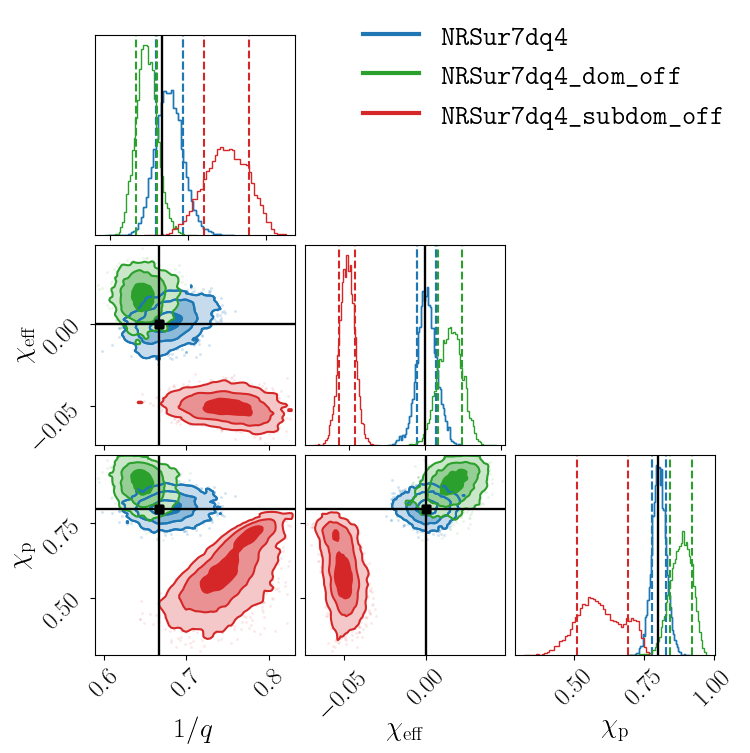

In [5]:
fig = bilby.result.plot_multiple(
    [
        posterior_NRSur7dq4,
        posterior_NRSur7dq4_dom_off,
        posterior_NRSur7dq4_subdom_off
    ],
    filename=None, 
    parameters={
        'mass_ratio': truths['mass_ratio'],
        'chi_eff': truths['chi_eff'],
        'chi_p': truths['chi_p']
    },
    corner_labels=[
            r'$1/q$', 
            r'$\chi_{\text{eff}}$', 
            r'$\chi_{\text{p}}$'
            ],
    labels=[],
    colours=['tab:blue', 'tab:green', 'tab:red'],
    smooth=True,
    title_kwargs=dict(fontsize=20, y=1.05),
    label_kwargs=dict(fontsize=20),
    truth_color='black'
)

# tick font size
for ax in fig.axes:
    ax.tick_params(labelsize=18)

# remove all legends on all axes (Bilby's ghost box lives here)
for ax in fig.axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove() 

# remove all titles on all axes
for ax in fig.axes:
    ax.set_title("")

# my new legend
handles = [
    Line2D([], [], color='tab:blue', lw=3, label=r'\texttt{NRSur7dq4}'),
    Line2D([], [], color='tab:green', lw=3, label=r'\texttt{NRSur7dq4\_dom\_off}'),
    Line2D([], [], color='tab:red', lw=3, label=r'\texttt{NRSur7dq4\_subdom\_off}')]
fig.legend(
    handles=handles,
    fontsize=20,
    loc='upper right',
    frameon=False)

fig.savefig('posteriors_small.pdf', bbox_inches='tight')
plt.show()
